# Метрики бинарной классификации

Покажем, как порог решения меняет precision, recall и F1, и сравним ROC-кривую с Precision-Recall-кривой на несбалансированных данных.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    f1_score,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

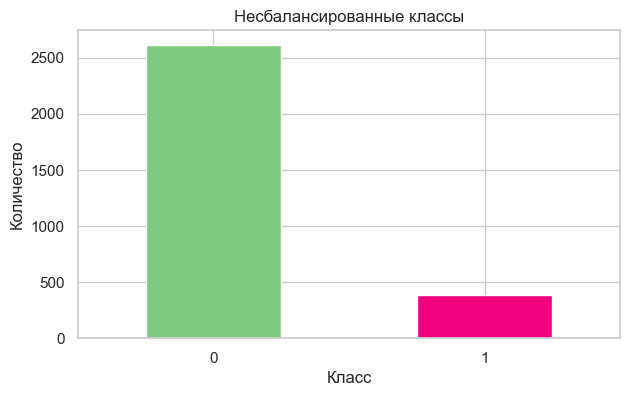

In [2]:
features, target = make_classification(
    n_samples=3000,
    n_features=16,
    n_informative=7,
    n_redundant=3,
    weights=[0.88, 0.12],
    class_sep=1.1,
    flip_y=0.02,
    random_state=42,
)
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.3, random_state=42, stratify=target
)

pd.Series(target).value_counts().sort_index().plot.bar(figsize=(7, 4), color=["#7fc97f", "#f0027f"])
plt.title("Несбалансированные классы")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.xticks(rotation=0)
plt.show()

In [3]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, random_state=42)),
])
model.fit(train_features, train_target)
probability = model.predict_proba(test_features)[:, 1]

precision, recall, thresholds = precision_recall_curve(test_target, probability)
f1_values = 2 * precision[:-1] * recall[:-1] / np.maximum(precision[:-1] + recall[:-1], 1e-12)
threshold_frame = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
    "f1": f1_values,
})
best_row = threshold_frame.loc[threshold_frame["f1"].idxmax()]
best_row.to_frame("value")

,value
threshold,0.266475
precision,0.656250
recall,0.724138
f1,0.688525


## Метрики при разных порогах

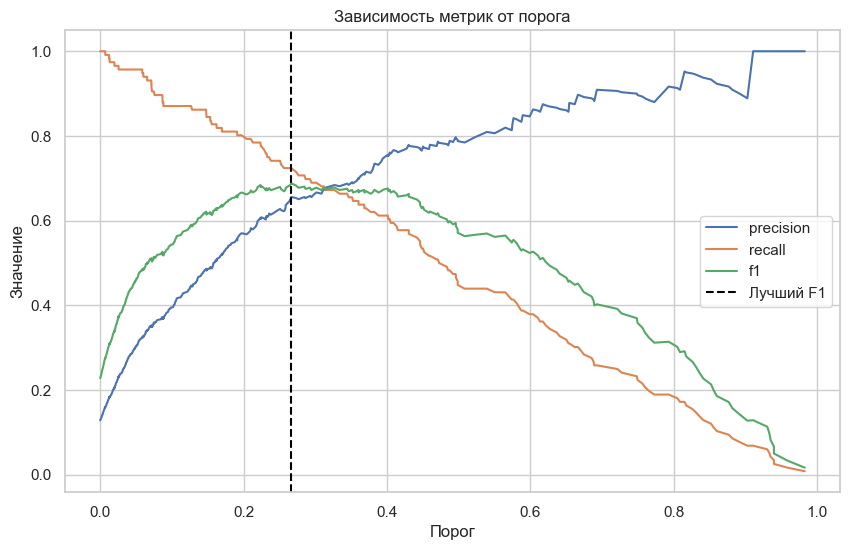

In [4]:
plt.figure(figsize=(10, 6))
for metric in ["precision", "recall", "f1"]:
    plt.plot(threshold_frame["threshold"], threshold_frame[metric], label=metric)
plt.axvline(best_row["threshold"], linestyle="--", color="black", label="Лучший F1")
plt.title("Зависимость метрик от порога")
plt.xlabel("Порог")
plt.ylabel("Значение")
plt.legend()
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


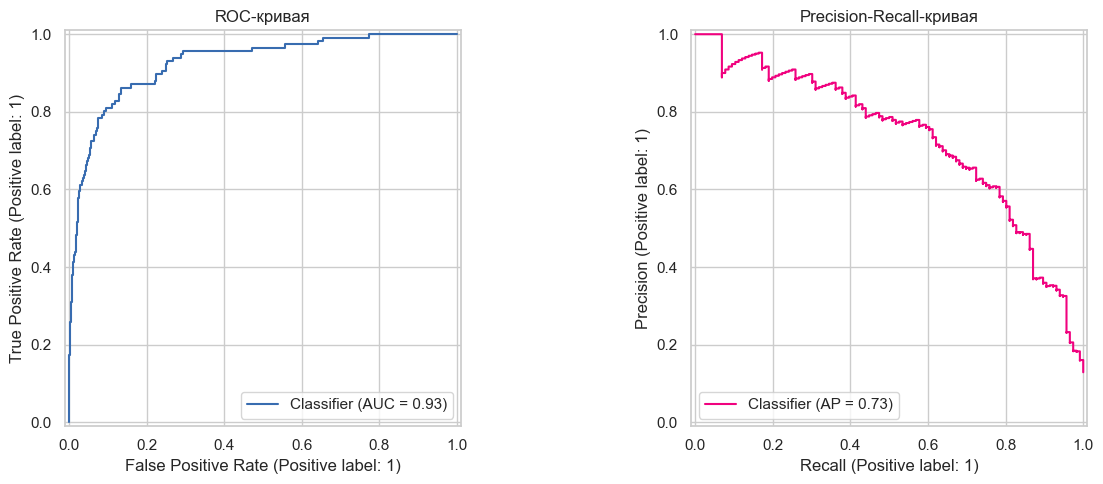

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(test_target, probability, ax=axes[0], color="#386cb0")
axes[0].set_title("ROC-кривая")
PrecisionRecallDisplay.from_predictions(test_target, probability, ax=axes[1], color="#f0027f")
axes[1].set_title("Precision-Recall-кривая")
plt.tight_layout()
plt.show()

## Матрицы ошибок

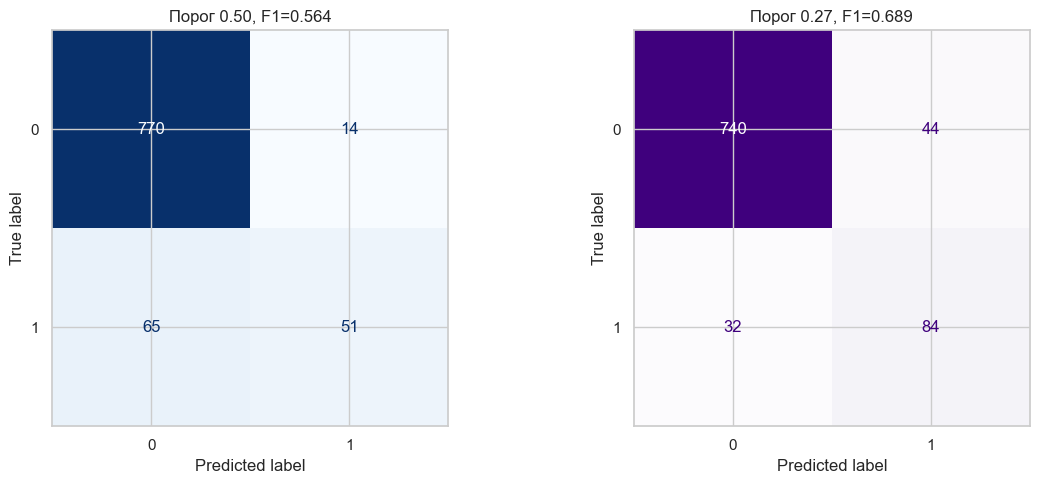

In [6]:
default_prediction = (probability >= 0.5).astype(int)
optimized_prediction = (probability >= best_row["threshold"]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(test_target, default_prediction, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Порог 0.50, F1={f1_score(test_target, default_prediction):.3f}")
ConfusionMatrixDisplay.from_predictions(test_target, optimized_prediction, ax=axes[1], cmap="Purples", colorbar=False)
axes[1].set_title(f"Порог {best_row['threshold']:.2f}, F1={f1_score(test_target, optimized_prediction):.3f}")
plt.tight_layout()
plt.show()

## Вывод

Порог 0.5 не всегда оптимален. Для редкого положительного класса Precision-Recall-кривая обычно информативнее ROC, а рабочий порог выбирают исходя из стоимости false positive и false negative.